In [43]:
import keras
import pandas as pd
import numpy as np
import math
import matplotlib as plt
import os
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [44]:
np.set_printoptions(threshold=np.inf)

In [45]:
#####DATA FORMATTING#####

train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

print(train.head())

print(test.head())

numeric_feats = train.select_dtypes(include=[np.number]).drop(
    columns=["Id", "SalePrice", "SalePrice_log"], errors="ignore").columns

print(numeric_feats)

import pandas as pd

def Data(train, test):
    train = train.copy()
    test = test.copy()

    # Save target
    y_train = np.log1p(train.pop("SalePrice").astype("int32"))

    # Remove IDs
    train.drop(columns=["Id"], inplace=True)
    test.drop(columns=["Id"], inplace=True)

    # Combine so train and test get identical columns
    combined = pd.concat([train, test], axis=0, ignore_index=True)

    # Fill missing numeric values
    numeric_cols = combined.select_dtypes(include=["number"]).columns
    combined[numeric_cols] = combined[numeric_cols].fillna(
        combined[numeric_cols].median()
    )
    min_max = MinMaxScaler()
    combined[numeric_cols] = np.round(min_max.fit_transform(combined[numeric_cols]),4)

    # Fill missing categorical values
    categorical_cols = combined.select_dtypes(include=["object"]).columns
    combined[categorical_cols] = combined[categorical_cols].fillna("Missing")

    # One-hot encode
    combined = pd.get_dummies(combined, dtype="int32")

    # Ensure all columns are int32
    combined = combined.astype("float32")

    # Split back while RETAINING column names
    x_train = combined.iloc[:len(train)].reset_index(drop=True)
    x_test = combined.iloc[len(train):].reset_index(drop=True)

    return x_train, x_test, y_train


x_train, x_test, y_train = Data(train, test)


print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(x_train.head)
# print(x_test)



   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [46]:
#####NORMAL_MODEL######

@keras.utils.register_keras_serializable(package="custom_layers")
class Normal_Model(keras.Model):
    def __init__(self, units, **kwargs):
        super(NormalModel, self).__init__(**kwargs)
        # print("CM__init__----")

        self.layer1 = keras.layers.Dense(units=2048,activation=keras.activations.leaky_relu)
        self.layer2 = keras.layers.Dense(units=1024, activation=keras.activations.leaky_relu)
        self.layer3 = keras.layers.Dense(units=512, activation=keras.activations.leaky_relu)
        self.final = keras.layers.Dense(units=1, activation=keras.activations.linear)
        pass

    def build(self, input_shape):
        # print("CMbuild----")
        #super.build()
        pass

    def call(self, inputs):
        # print("CMcall----")
        x1 = self.layer1(inputs)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.final(x3)
        return x4

In [47]:
#####GA_MODEL######

@keras.utils.register_keras_serializable(package="custom_layers")
class Genetic_Algorithm(keras.layers.Layer):
    def __init__(self, name=None, kernel_initializer=None, **kwargs):
        print("CLK__init__----")
        super().__init__(**kwargs)

        self.population_size = 20
        self.population = None
        self.x_train, _, self.y_train = Data(train, test)

    def build(self, input_shape):
        print("CLKbuild----")
        print(input_shape)

        num_features = input_shape[-1]

        self.population = tf.Variable(
            tf.random.normal((self.population_size, num_features)),
            trainable=False,
            dtype=tf.float32,
        )

        super().build(input_shape)

    def call(self, inputs, model):
        rinputs, kept = Reduce(self.x_train)
        ry_train = tf.gather(self.y_train, kept)
        losses = Evaluate_Genes(self.population, model, rinputs, ry_train)
        new_population, best_gene = Evolve(self.population, losses)
        self.population.assign(new_population)
        return inputs * best_gene

@keras.utils.register_keras_serializable(package="custom_layers")
class GA_Model(keras.Model):
    def __init__(self, units, **kwargs):
        super(GA_Model, self).__init__(**kwargs)
        print("CM__init__----")
        self.GA = Genetic_Algorithm(name="GA")
        self.layer1 = keras.layers.Dense(units=2048,activation=keras.activations.leaky_relu)
        self.layer2 = keras.layers.Dense(units=1024, activation=keras.activations.leaky_relu)
        self.layer3 = keras.layers.Dense(units=512, activation=keras.activations.leaky_relu)
        self.final = keras.layers.Dense(units=1, activation=keras.activations.sigmoid)
        pass

    def build(self, input_shape):
        print("CMbuild----")
        #super.build()
        pass

    def call(self, inputs):
        print("CMcall----")
        x1 = self.layer1(inputs)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.GA(x2, model=[self.layer1, self.layer2, self.layer3, "GA", self.final])
        x5 = self.final(x4)
        return x5

In [48]:
#####FUNCTIONS######

def unscaled_rmse(y_true, y_pred):
    y_true_orig = tf.math.expm1(y_true)
    y_pred_orig = tf.math.expm1(y_pred)
    return tf.sqrt(tf.reduce_mean(tf.square(y_true_orig - y_pred_orig)))

def Plot_Loss(Data, Title, split):
    n_groups = max(split) + 1
    fig, axes = plt.pyplot.subplots(n_groups, 1, figsize=(8, 4 * n_groups))
    if n_groups == 1:
        axes = [axes]  # keep indexing consistent if there's only one group

    for z in range(len(Data)):
        ax = axes[split[z]]
        ploty = Data[z]
        skip  = len(ploty) // 10
        ploty = ploty[skip:]
        plotx = np.linspace(0, len(ploty), len(ploty))
        ax.plot(plotx, ploty, label=Title[z])

    for ax in axes:
        ax.yaxis.set_major_locator(plt.ticker.MaxNLocator(10))
        ax.legend()

    # ax.set_yscale("log")
    # ax.set_xscale("log")
    plt.pyplot.savefig("plot.png")

CM__init__----
CLK__init__----
Epoch 1/100
39/39 - 1s - 32ms/step - loss: 4.2808e-04 - unscaled_rmse: 4265.8447 - val_loss: 0.0362 - val_unscaled_rmse: 46172.5195
Epoch 2/100
39/39 - 1s - 31ms/step - loss: 5.0059e-04 - unscaled_rmse: 4553.8350 - val_loss: 0.0361 - val_unscaled_rmse: 45401.0938
Epoch 3/100
39/39 - 1s - 31ms/step - loss: 4.8309e-04 - unscaled_rmse: 4552.1460 - val_loss: 0.0387 - val_unscaled_rmse: 49194.0547
Epoch 4/100
39/39 - 1s - 31ms/step - loss: 9.2049e-04 - unscaled_rmse: 5943.7300 - val_loss: 0.0386 - val_unscaled_rmse: 47769.0898
Epoch 5/100
39/39 - 1s - 32ms/step - loss: 0.0011 - unscaled_rmse: 6395.8721 - val_loss: 0.0383 - val_unscaled_rmse: 48523.5234
Epoch 6/100
39/39 - 1s - 33ms/step - loss: 0.0012 - unscaled_rmse: 6461.9517 - val_loss: 0.0367 - val_unscaled_rmse: 46634.9258
Epoch 7/100
39/39 - 1s - 31ms/step - loss: 7.5636e-04 - unscaled_rmse: 5350.8550 - val_loss: 0.0353 - val_unscaled_rmse: 44768.1250
Epoch 8/100
39/39 - 1s - 33ms/step - loss: 7.3022e-04

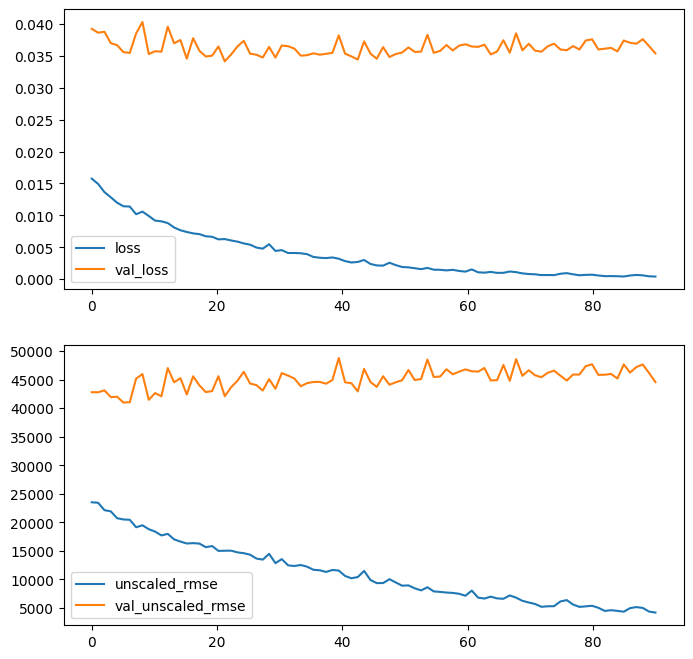

In [49]:
ES = keras.callbacks.EarlyStopping(monitor='loss',patience=3, restore_best_weights=True)
# model = Normal_Model(2)
model = GA_Model(2)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001), 
    loss=keras.losses.MeanSquaredError(),
    metrics=[unscaled_rmse]
)

EPOCHS = 100

history = model1.fit(x_train, y_train, epochs=EPOCHS, verbose=2, validation_split=0.15)



Plot_Loss([
    history1.history["loss"],
    history1.history["unscaled_rmse"],
    history1.history["val_loss"],
    history1.history["val_unscaled_rmse"]
], [
    "loss",
    "unscaled_rmse",
    "val_loss",
    "val_unscaled_rmse"
], [
    0,
    1,
    0,
    1
]
         )


########TODO########### WHEN GETTING PREDICTIONS ON TEST, np.expm1 IT#############TODO#########